# Unified Baseline Tea Price Forecasting Model
**CTA (Colombo Tea Auction) — All Segments Pooled**

This notebook builds a simple, interpretable **unified (pooled) baseline** that predicts `price_mid_lkr` across all four tea segments:
- High Grown
- Low Grown
- Off-Grade
- Dust

**Design goals:**
- Time-series discipline: sort by date (not sale number), use chronological train/test split
- Feature selection via Random Forest importances (keeping model interpretable)
- Hyperparameter tuning with Optuna
- Clear evaluation: RMSE, MAE, MAPE, R²

This serves as the **pooled baseline** against which segment-specific models are compared in the paper.

## 1. Imports & Configuration

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import optuna

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)

# Plotting style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

print('All libraries loaded successfully.')

d:\Projects\data-analysis-for-tea-industry\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries loaded successfully.


## 2. Load & Parse Data

In [2]:
df_raw = pd.read_csv('../data/processed/tea_preprocessed_v3.csv', low_memory=False)
print(f'Raw dataset shape: {df_raw.shape}')
df_raw[['sale_date_raw', 'category_type', 'price_mid_lkr']].head(4)

Raw dataset shape: (5069, 220)


,sale_date_raw,category_type,price_mid_lkr
0,10TH/11TH January 2024,dust,1125.0
1,10TH/11TH January 2024,dust,1070.0
2,10TH/11TH January 2024,dust,1230.0
3,10TH/11TH January 2024,dust,950.0


In [3]:
# -------------------------------------------------------------------
# Parse sale date from the raw string, e.g. '06TH/07TH January 2026'
# Time-series discipline: sort by DATE, not sale_number.
# sale_number is NOT unique across years, so date-based sorting is correct.
# -------------------------------------------------------------------

def parse_sale_date(raw):
    """Extract the first date from strings like '06TH/07TH January 2026'."""
    raw = str(raw)
    m = re.search(r'(\d+)[A-Z]{2}(?:/\d+[A-Z]{2})?\s+(\w+)\s+(\d{4})', raw, re.IGNORECASE)
    if m:
        return pd.to_datetime(f"{m.group(1)} {m.group(2)} {m.group(3)}",
                              format='%d %B %Y', errors='coerce')
    return pd.NaT

df_raw = df_raw.copy()
df_raw['sale_date'] = df_raw['sale_date_raw'].apply(parse_sale_date)

# Drop rows where date or target is missing
df = df_raw.dropna(subset=['sale_date', 'price_mid_lkr']).copy()

# Sort CHRONOLOGICALLY by date (time-series discipline)
df = df.sort_values('sale_date').reset_index(drop=True)

print(f'After dropping nulls: {df.shape[0]} rows')
print(f'Date range : {df["sale_date"].min().date()} → {df["sale_date"].max().date()}')
print(f'Unique sale dates : {df["sale_date"].nunique()}')
print(f'Category distribution:')
print(df['category_type'].value_counts().to_string())

After dropping nulls: 4923 rows
Date range : 2023-11-01 → 2026-03-24
Unique sale dates : 37
Category distribution:
category_type
low_grown     1921
high_grown    1393
off_grade      843
dust           766


## 3. Feature Engineering & Selection

The dataset has ~247 columns. We select a meaningful subset across five groups:
1. **Structural / market** — supply-demand indicators, volume, reprint ratio
2. **Segment / grade encodings** — category_type, elevation, tier
3. **Sentiment** — broker report sentiment scores
4. **Weather (current + lags)** — precipitation, sunshine, temperature per region
5. **Rolling stats** — 3-sale moving averages of price and volume

A Random Forest is then used to rank importances and retain the top-N features.

In [4]:
# ---------------------------------------------------------------
# Candidate feature pool (deliberately broad for initial RF pass)
# ---------------------------------------------------------------

STRUCTURAL = [
    'total_lots', 'total_kgs', 'reprint_lots', 'reprint_quantity',
    'supply_pressure_index', 'demand_intensity_ratio', 'market_tightness_indicator',
    'volume_yoy_change_pct', 'total__qty_mkgs',
    'dust__demand_score', 'off_grade__demand_score',
    'sl_production_mkgs', 'is_production_known',
    'total_sold_weekly_2026', 'public_auction_weekly_2026',
    'price_range_lkr',                   # spread, not leakage (it's input-side)
    'roll3_mean__price_mid_lkr',         # 3-sale rolling average of target
    'roll3_std__price_mid_lkr',
    'roll3_mean__total__qty_mkgs',
    'roll3_mean__volume_yoy_change_pct',
]

CATEGORICAL_ENC = [
    'category_type_enc', 'elevation_enc', 'tier_enc',
    'table_source_enc', 'sale_month_enc',
]

SENTIMENT = [
    'sentiment_overall', 'sentiment_ex_estate', 'sentiment_low_grown',
    'western_nuwara_eliya_weather_score', 'uva_udapussellawa_weather_score',
    'low_grown_weather_score', 'avg_weather_severity',
]

WEATHER_CURRENT = [
    'all_regions__avg_precipitation',
    'low_grown__precipitation_sum_total',
    'nuwara_eliya__precipitation_sum_total',
    'uva_udapussellawa__precipitation_sum_total',
    'western_high__precipitation_sum_total',
    'low_grown__sunshine_duration_total',
    'nuwara_eliya__sunshine_duration_total',
    'uva_udapussellawa__sunshine_duration_total',
    'western_high__sunshine_duration_total',
    'low_grown__temperature_2m_mean_mean',
    'nuwara_eliya__temperature_2m_mean_mean',
    'uva_udapussellawa__temperature_2m_mean_mean',
    'western_high__temperature_2m_mean_mean',
]

WEATHER_LAG = [
    'low_grown__precipitation_sum_total_lag1',
    'nuwara_eliya__precipitation_sum_total_lag1',
    'western_high__precipitation_sum_total_lag1',
    'low_grown__sunshine_duration_total_lag1',
    'nuwara_eliya__sunshine_duration_total_lag1',
    'western_high__sunshine_duration_total_lag1',
    'low_grown__temperature_2m_mean_mean_lag1',
    'nuwara_eliya__temperature_2m_mean_mean_lag1',
    'western_high__temperature_2m_mean_mean_lag1',
    'low_grown__sunshine_duration_total_lag2',
    'nuwara_eliya__sunshine_duration_total_lag2',
    'low_grown__temperature_2m_mean_mean_lag2',
    'nuwara_eliya__temperature_2m_mean_mean_lag2',
    'roll3_mean__all_regions__avg_precipitation',
    'roll3_mean__low_grown__sunshine_duration_total',
    'roll3_mean__western_high__sunshine_duration_total',
    'roll3_mean__low_grown__temperature_2m_mean_mean',
    'roll3_mean__western_high__temperature_2m_mean_mean',
]

CANDIDATE_FEATURES = STRUCTURAL + CATEGORICAL_ENC + SENTIMENT + WEATHER_CURRENT + WEATHER_LAG

# Keep only features that actually exist in the dataframe
CANDIDATE_FEATURES = [f for f in CANDIDATE_FEATURES if f in df.columns]
print(f'Candidate feature pool: {len(CANDIDATE_FEATURES)} features')

Candidate feature pool: 60 features


In [5]:
# Build feature matrix — drop rows with any NaN in candidate features
TARGET = 'price_mid_lkr'

model_df = df[CANDIDATE_FEATURES + [TARGET, 'sale_date', 'category_type']].dropna().copy()
model_df = model_df.sort_values('sale_date').reset_index(drop=True)

X_all = model_df[CANDIDATE_FEATURES]
y_all = model_df[TARGET]

print(f'Modelling dataset: {model_df.shape[0]} rows × {len(CANDIDATE_FEATURES)} candidate features')
print(f'Target (price_mid_lkr): mean={y_all.mean():.1f}, std={y_all.std():.1f}, '
      f'min={y_all.min():.1f}, max={y_all.max():.1f}')
print(f'\nSegment breakdown after cleaning:')
print(model_df['category_type'].value_counts().to_string())

Modelling dataset: 4528 rows × 60 candidate features
Target (price_mid_lkr): mean=1258.1, std=611.4, min=520.0, max=6750.0

Segment breakdown after cleaning:
category_type
low_grown     1803
high_grown    1240
off_grade      774
dust           711


In [6]:
# -----------------------------------------------------------
# Feature Selection: rank importances with a quick RF,
# then keep the top-25 features for the final model.
# Using TimeSeriesSplit to preserve temporal order.
# -----------------------------------------------------------

N_TOP = 25

selector_rf = RandomForestRegressor(n_estimators=200, max_depth=10,
                                     random_state=SEED, n_jobs=-1)
selector_rf.fit(X_all, y_all)

importances = pd.Series(selector_rf.feature_importances_, index=CANDIDATE_FEATURES)
importances = importances.sort_values(ascending=False)

TOP_FEATURES = importances.head(N_TOP).index.tolist()

print(f'Top {N_TOP} features selected:')
for rank, (feat, imp) in enumerate(importances.head(N_TOP).items(), 1):
    print(f'  {rank:2d}. {feat:<55s}  importance={imp:.4f}')

Top 25 features selected:
   1. tier_enc                                                 importance=0.4107
   2. price_range_lkr                                          importance=0.2351
   3. roll3_std__price_mid_lkr                                 importance=0.1545
   4. roll3_mean__price_mid_lkr                                importance=0.1157
   5. table_source_enc                                         importance=0.0403
   6. category_type_enc                                        importance=0.0076
   7. elevation_enc                                            importance=0.0039
   8. uva_udapussellawa__temperature_2m_mean_mean              importance=0.0022
   9. nuwara_eliya__temperature_2m_mean_mean_lag1              importance=0.0019
  10. nuwara_eliya__temperature_2m_mean_mean                   importance=0.0013
  11. nuwara_eliya__temperature_2m_mean_mean_lag2              importance=0.0012
  12. western_high__temperature_2m_mean_mean_lag1              importance=0.0011
  

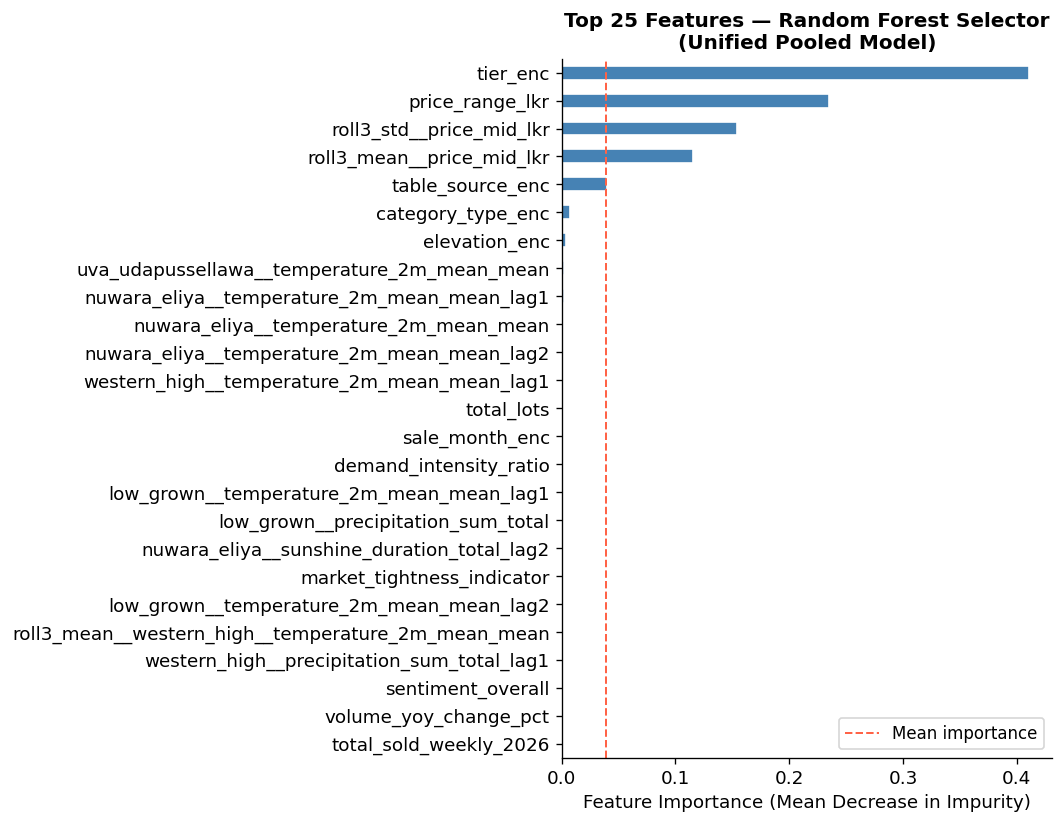

Figure saved.


In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
importances.head(N_TOP).sort_values().plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title(f'Top {N_TOP} Features — Random Forest Selector\n(Unified Pooled Model)', fontsize=12, fontweight='bold')
ax.axvline(importances.head(N_TOP).mean(), color='tomato', ls='--', lw=1.2, label='Mean importance')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../reports/figures/feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 4. Train/Test Split (Chronological)

Use the last ~20% of sales dates as the held-out test set. This preserves temporal ordering — no data leakage from future sales.

In [8]:
X = model_df[TOP_FEATURES]
y = model_df[TARGET]
dates = model_df['sale_date']

# Chronological 80/20 split
split_idx = int(len(X) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_train, dates_test = dates.iloc[:split_idx], dates.iloc[split_idx:]

print(f'Training set : {len(X_train):4d} rows  '
      f'({dates_train.min().date()} → {dates_train.max().date()})')
print(f'Test set     : {len(X_test):4d} rows  '
      f'({dates_test.min().date()} → {dates_test.max().date()})')

# TimeSeriesSplit for cross-validation during tuning
tscv = TimeSeriesSplit(n_splits=5)

Training set : 3622 rows  (2023-11-28 → 2025-08-26)
Test set     :  906 rows  (2025-08-26 → 2026-03-24)


## 5. Pre-Tuning Baseline: Default Gradient Boosting

Run default GBM first so we can quantify the improvement from tuning.

In [9]:
def compute_metrics(y_true, y_pred, label=''):
    """Return a dict of forecasting metrics."""
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    mask  = y_true != 0
    mape  = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    r2    = r2_score(y_true, y_pred)
    if label:
        print(f'\n── {label} ──')
        print(f'  RMSE : {rmse:>8.2f} LKR')
        print(f'  MAE  : {mae:>8.2f} LKR')
        print(f'  MAPE : {mape:>8.2f} %')
        print(f'  R²   : {r2:>8.4f}')
    return dict(RMSE=rmse, MAE=mae, MAPE=mape, R2=r2)

# Default GBM
gbm_default = GradientBoostingRegressor(random_state=SEED)
gbm_default.fit(X_train, y_train)
pred_default = gbm_default.predict(X_test)
metrics_default = compute_metrics(y_test.values, pred_default, 'Default GBM (pre-tuning) — Test Set')


── Default GBM (pre-tuning) — Test Set ──
  RMSE :   189.77 LKR
  MAE  :   137.08 LKR
  MAPE :    12.09 %
  R²   :   0.8797


## 6. Hyperparameter Tuning with Optuna

Search space covers the key GBM knobs: tree depth, learning rate, subsampling, and regularisation. Cross-validation uses `TimeSeriesSplit(n_splits=5)` to prevent look-ahead leakage.

In [10]:
def objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 100, 600, step=50),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        max_depth         = trial.suggest_int('max_depth', 2, 6),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 5, 50),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2', 1.0]),
        random_state      = SEED,
    )
    model = GradientBoostingRegressor(**params)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    return -scores.mean()   # minimise RMSE

study = optuna.create_study(direction='minimize',
                             sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=80, show_progress_bar=True)

print(f'\nBest CV RMSE : {study.best_value:.2f} LKR')
print('Best params  :')
for k, v in study.best_params.items():
    print(f'  {k:<22s}: {v}')

Best trial: 43. Best value: 198.763: 100%|██████████| 80/80 [02:42<00:00,  2.03s/it]


Best CV RMSE : 198.76 LKR
Best params  :
  n_estimators          : 600
  learning_rate         : 0.015558266943235012
  max_depth             : 5
  min_samples_leaf      : 5
  subsample             : 0.7363657981057367
  max_features          : 1.0


## 7. Train Tuned Model & Evaluate on Test Set

In [11]:
best_params = dict(**study.best_params, random_state=SEED)
gbm_tuned = GradientBoostingRegressor(**best_params)
gbm_tuned.fit(X_train, y_train)
pred_tuned = gbm_tuned.predict(X_test)
metrics_tuned = compute_metrics(y_test.values, pred_tuned, 'Tuned GBM (post-tuning) — Test Set')


── Tuned GBM (post-tuning) — Test Set ──
  RMSE :   180.75 LKR
  MAE  :   129.34 LKR
  MAPE :    11.65 %
  R²   :   0.8908


In [12]:
# Cross-validation performance of tuned model on training data
cv_scores = cross_val_score(
    gbm_tuned, X_train, y_train,
    cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1
)
cv_rmse = -cv_scores
print('\n── Tuned GBM — 5-Fold TimeSeriesSplit CV (training data) ──')
print(f'  Per-fold RMSE: {[round(v,2) for v in cv_rmse]}')
print(f'  Mean CV RMSE : {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f} LKR')


── Tuned GBM — 5-Fold TimeSeriesSplit CV (training data) ──
  Per-fold RMSE: [np.float64(208.0), np.float64(183.23), np.float64(173.67), np.float64(231.4), np.float64(197.52)]
  Mean CV RMSE : 198.76 ± 20.11 LKR


## 8. Per-Segment Breakdown on Test Set

Even though this is a unified (pooled) model, we report metrics per segment — this is required for the comparison with segment-specific models.

In [13]:
test_df = model_df.iloc[split_idx:].copy()
test_df['pred_tuned'] = pred_tuned

segment_results = []
print('── Per-Segment Test Metrics (Unified Pooled Model) ──\n')

for seg in ['high_grown', 'low_grown', 'off_grade', 'dust']:
    mask = test_df['category_type'] == seg
    if mask.sum() == 0:
        continue
    yt = test_df.loc[mask, TARGET].values
    yp = test_df.loc[mask, 'pred_tuned'].values
    m = compute_metrics(yt, yp, label=f'{seg.replace("_"," ").title()}')
    m['segment'] = seg
    m['n_obs'] = mask.sum()
    segment_results.append(m)

seg_df = pd.DataFrame(segment_results).set_index('segment')
seg_df = seg_df[['n_obs','RMSE','MAE','MAPE','R2']]
seg_df.columns = ['N', 'RMSE (LKR)', 'MAE (LKR)', 'MAPE (%)', 'R²']
print('\n── Summary Table ──')
print(seg_df.to_string(float_format=lambda x: f'{x:.3f}'))

── Per-Segment Test Metrics (Unified Pooled Model) ──


── High Grown ──
  RMSE :   163.20 LKR
  MAE  :   126.28 LKR
  MAPE :    11.19 %
  R²   :   0.4360

── Low Grown ──
  RMSE :   207.15 LKR
  MAE  :   133.73 LKR
  MAPE :     8.25 %
  R²   :   0.9085

── Off Grade ──
  RMSE :   157.25 LKR
  MAE  :   120.45 LKR
  MAPE :    17.88 %
  R²   :   0.1129

── Dust ──
  RMSE :   161.16 LKR
  MAE  :   132.98 LKR
  MAPE :    13.83 %
  R²   :   0.3132

── Summary Table ──
              N  RMSE (LKR)  MAE (LKR)  MAPE (%)    R²
segment                                               
high_grown  232     163.202    126.279    11.194 0.436
low_grown   361     207.148    133.733     8.246 0.908
off_grade   161     157.247    120.449    17.875 0.113
dust        152     161.157    132.977    13.835 0.313


## 9. Final Metrics Summary

In [14]:
print('=' * 60)
print('  UNIFIED BASELINE MODEL — FINAL METRICS SUMMARY')
print('=' * 60)

rows = [
    ('Pre-tuning (default GBM)', metrics_default),
    ('Post-tuning (Optuna GBM)', metrics_tuned),
]

header = f"{'Model':<30s}{'RMSE (LKR)':>12}{'MAE (LKR)':>12}{'MAPE (%)':>10}{'R²':>8}"
print(header)
print('-' * 72)
for name, m in rows:
    print(f"{name:<30s}{m['RMSE']:>12.2f}{m['MAE']:>12.2f}{m['MAPE']:>10.2f}{m['R2']:>8.4f}")

print('-' * 72)

# Improvement
rmse_imp = (metrics_default['RMSE'] - metrics_tuned['RMSE']) / metrics_default['RMSE'] * 100
mae_imp  = (metrics_default['MAE']  - metrics_tuned['MAE'])  / metrics_default['MAE']  * 100
print(f'\nTuning improvement — RMSE: {rmse_imp:+.1f}%  |  MAE: {mae_imp:+.1f}%')

print(f'\nCV (5-fold TSS) RMSE : {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f} LKR')
print(f'Test set size        : {len(X_test)} observations')
print(f'Training set size    : {len(X_train)} observations')
print(f'Features used        : {len(TOP_FEATURES)}')
print(f'Tuning trials        : 80  (Optuna TPE sampler)')
print('=' * 60)

  UNIFIED BASELINE MODEL — FINAL METRICS SUMMARY
Model                           RMSE (LKR)   MAE (LKR)  MAPE (%)      R²
------------------------------------------------------------------------
Pre-tuning (default GBM)            189.77      137.08     12.09  0.8797
Post-tuning (Optuna GBM)            180.75      129.34     11.65  0.8908
------------------------------------------------------------------------

Tuning improvement — RMSE: +4.8%  |  MAE: +5.7%

CV (5-fold TSS) RMSE : 198.76 ± 20.11 LKR
Test set size        : 906 observations
Training set size    : 3622 observations
Features used        : 25
Tuning trials        : 80  (Optuna TPE sampler)


## 10. Visualisations

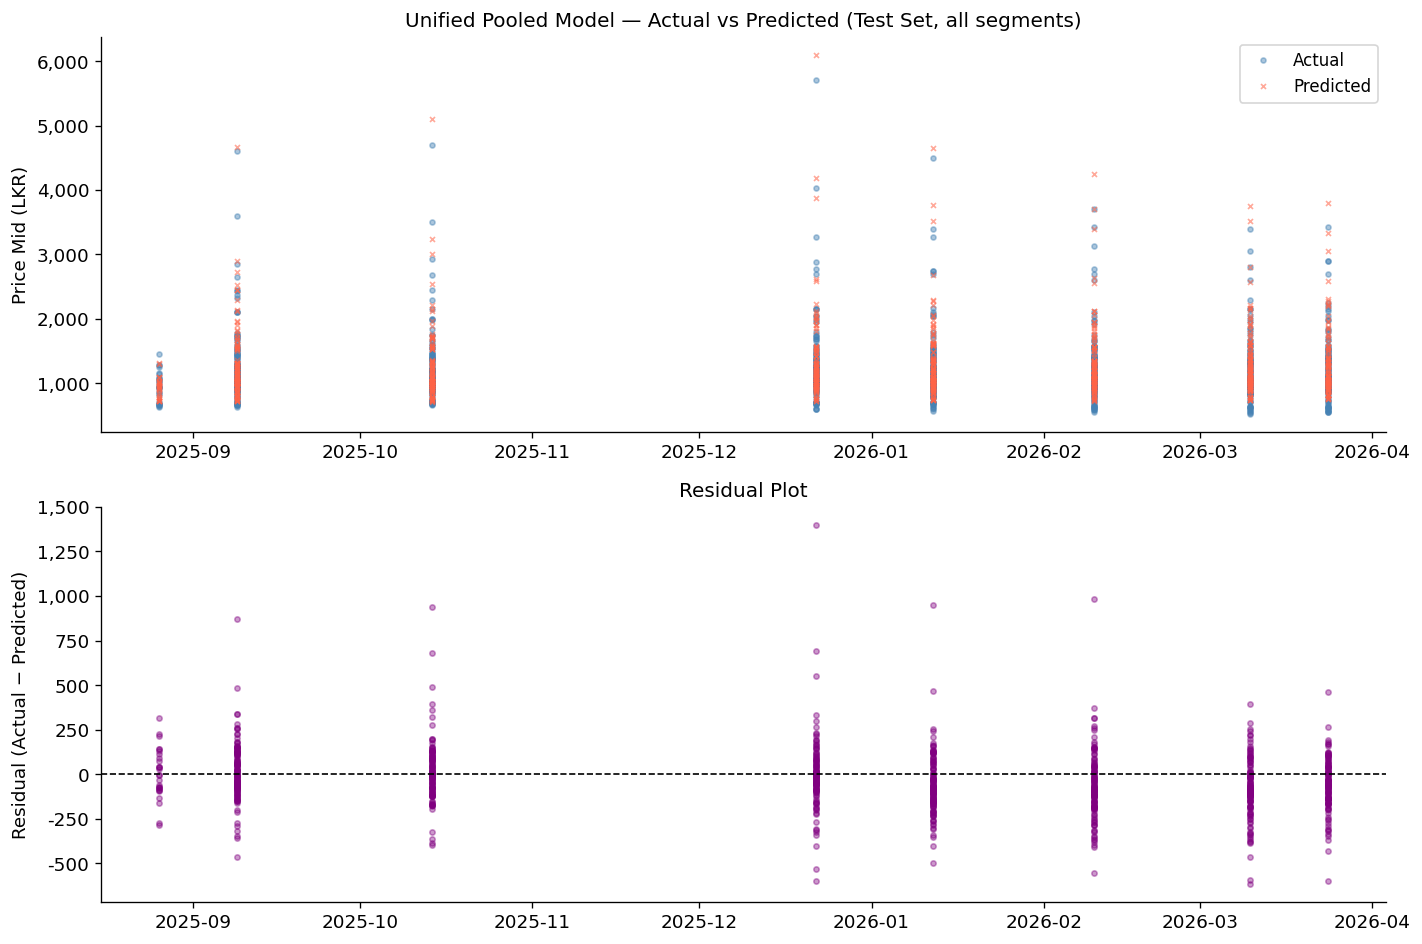

In [15]:
# --- Plot A: Actual vs Predicted (test set, sorted by date) ---

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Top: All-segment actual vs predicted
ax = axes[0]
ax.plot(dates_test.values, y_test.values, 'o', color='steelblue',
        alpha=0.45, markersize=3, label='Actual')
ax.plot(dates_test.values, pred_tuned, 'x', color='tomato',
        alpha=0.55, markersize=3, label='Predicted')
ax.set_ylabel('Price Mid (LKR)', fontsize=11)
ax.set_title('Unified Pooled Model — Actual vs Predicted (Test Set, all segments)', fontsize=12)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Bottom: Residuals
ax2 = axes[1]
residuals = y_test.values - pred_tuned
ax2.scatter(dates_test.values, residuals, alpha=0.4, s=10, color='purple')
ax2.axhline(0, color='black', lw=1, ls='--')
ax2.set_ylabel('Residual (Actual − Predicted)', fontsize=11)
ax2.set_title('Residual Plot', fontsize=12)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../reports/figures/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

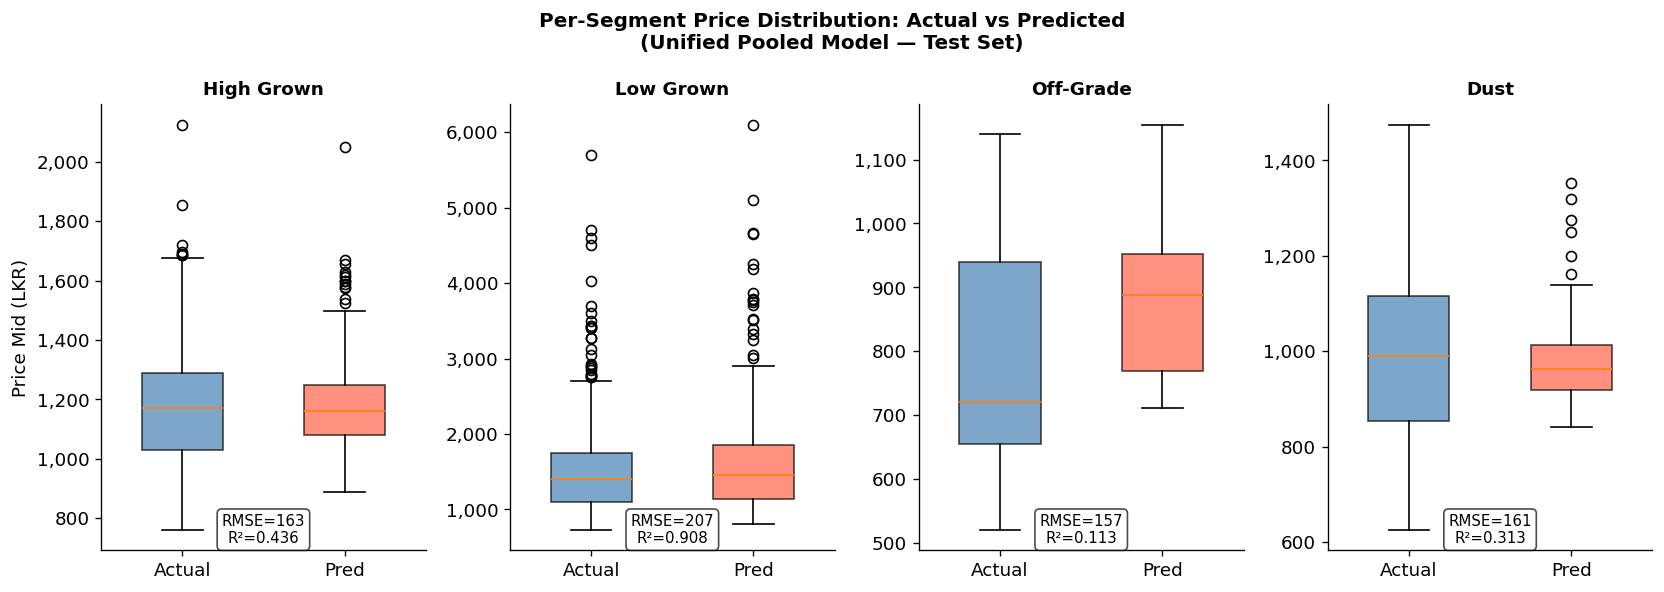

In [16]:
# --- Plot B: Per-segment actual vs predicted box comparison ---

SEGMENT_LABELS = {
    'high_grown': 'High Grown',
    'low_grown': 'Low Grown',
    'off_grade': 'Off-Grade',
    'dust': 'Dust',
}
SEGMENTS = list(SEGMENT_LABELS.keys())
COLORS = {'Actual': 'steelblue', 'Predicted': 'tomato'}

fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=False)

for ax, seg in zip(axes, SEGMENTS):
    mask = test_df['category_type'] == seg
    act = test_df.loc[mask, TARGET].values
    prd = test_df.loc[mask, 'pred_tuned'].values
    bp = ax.boxplot([act, prd], labels=['Actual', 'Pred'],
                    patch_artist=True, widths=0.5, notch=False)
    for patch, color in zip(bp['boxes'], ['steelblue', 'tomato']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(SEGMENT_LABELS[seg], fontsize=11, fontweight='bold')
    ax.set_ylabel('Price Mid (LKR)' if seg == 'high_grown' else '')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    # Annotate RMSE
    seg_m = seg_df.loc[seg]
    ax.text(0.5, 0.01,
            f"RMSE={seg_m['RMSE (LKR)']:.0f}\nR²={seg_m['R²']:.3f}",
            transform=ax.transAxes, ha='center', va='bottom',
            fontsize=9, color='black',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

fig.suptitle('Per-Segment Price Distribution: Actual vs Predicted\n(Unified Pooled Model — Test Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/per_segment_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

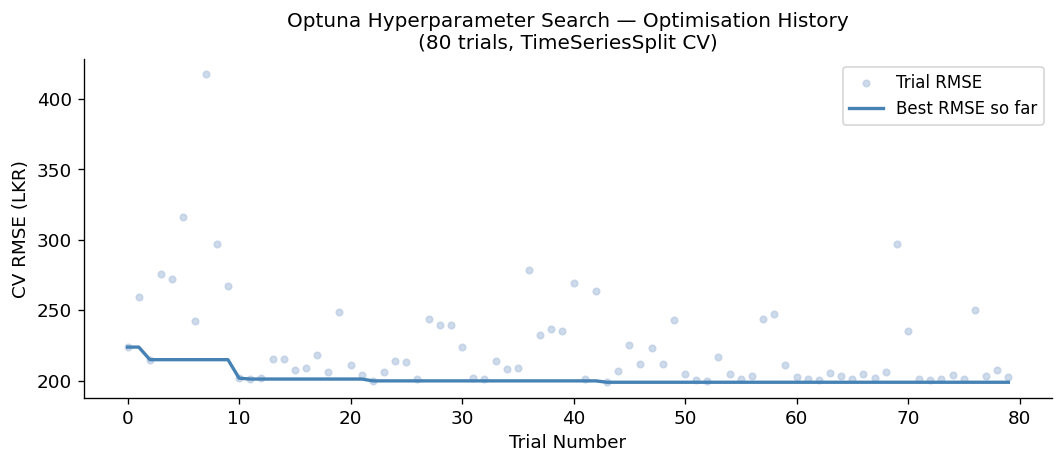

Best trial: #43  |  CV RMSE = 198.76 LKR


In [17]:
# --- Plot C: Optuna optimisation history ---

trial_values = [t.value for t in study.trials if t.value is not None]
best_so_far  = pd.Series(trial_values).cummin()

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(range(len(trial_values)), trial_values,
           color='lightsteelblue', s=15, alpha=0.6, label='Trial RMSE')
ax.plot(range(len(best_so_far)), best_so_far,
        color='steelblue', lw=2, label='Best RMSE so far')
ax.set_xlabel('Trial Number')
ax.set_ylabel('CV RMSE (LKR)')
ax.set_title('Optuna Hyperparameter Search — Optimisation History\n(80 trials, TimeSeriesSplit CV)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../reports/figures/optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best trial: #{study.best_trial.number}  |  CV RMSE = {study.best_value:.2f} LKR')

In [20]:
# --- Final consolidated print (easy copy for paper table) ---

print()
print('╔══════════════════════════════════════════════════════════════╗')
print('║         UNIFIED BASELINE — FINAL RESULTS (PAPER TABLE)       ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Model  : Gradient Boosting Regressor (Pooled, all segments)║')
print(f'║  Features: Top-{N_TOP} by RF importance out of {len(CANDIDATE_FEATURES)} candidates ║')
print(f'║  Split  : Chronological 80/20 (date-sorted)                 ║')
print(f'║  CV     : 5-Fold TimeSeriesSplit on training set            ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  OVERALL TEST SET PERFORMANCE (Tuned Model)                 ║')
print(f'║    RMSE  : {metrics_tuned["RMSE"]:>10.2f} LKR               ║')
print(f'║    MAE   : {metrics_tuned["MAE"]:>10.2f} LKR                ║')
print(f'║    MAPE  : {metrics_tuned["MAPE"]:>10.2f} %                 ║')
print(f'║    R²    : {metrics_tuned["R2"]:>10.4f}                     ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  CV RMSE : {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f} LKR (5-fold TSS)║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  PER-SEGMENT BREAKDOWN (Test Set):                          ║')
for _, row in seg_df.iterrows():
    seg_name = row.name.replace('_', ' ').title()
    print(f'║    {seg_name:<12s}  RMSE={row["RMSE (LKR)"]:>7.1f}  MAE={row["MAE (LKR)"]:>7.1f}  R²={row["R²"]:>6.4f}  ║')
print('╚══════════════════════════════════════════════════════════════╝')


╔══════════════════════════════════════════════════════════════╗
║         UNIFIED BASELINE — FINAL RESULTS (PAPER TABLE)       ║
╠══════════════════════════════════════════════════════════════╣
║  Model  : Gradient Boosting Regressor (Pooled, all segments)║
║  Features: Top-25 by RF importance out of 60 candidates ║
║  Split  : Chronological 80/20 (date-sorted)                 ║
║  CV     : 5-Fold TimeSeriesSplit on training set            ║
╠══════════════════════════════════════════════════════════════╣
║  OVERALL TEST SET PERFORMANCE (Tuned Model)                 ║
║    RMSE  :     180.75 LKR               ║
║    MAE   :     129.34 LKR                ║
║    MAPE  :      11.65 %                 ║
║    R²    :     0.8908                     ║
╠══════════════════════════════════════════════════════════════╣
║  CV RMSE : 198.76 ± 20.11 LKR (5-fold TSS)║
╠══════════════════════════════════════════════════════════════╣
║  PER-SEGMENT BREAKDOWN (Test Set):                          ║
║   